# College Project: Comparative Analysis of BNNs on PovertyMap (WILDS)

## 1. Introduction and Theoretical Background
In this project, we compare two distinct approaches to estimating epistemic and aleatoric uncertainty in Bayesian Neural Networks (BNNs) on the **PovertyMap** dataset from the WILDS benchmark. This task involves predicting the asset wealth index from satellite imagery using a ResNet-18 architecture, and evaluating in-distribution (ID) versus out-of-distribution (OOD) generalization across different country folds.

**Laplace method (following Daxberger et al. "Laplace Redux"):**
- *Theory*: Last-layer Laplace with **full** covariance approximation ($\mathcal{N}(w_{MAP}, H^{-1})$).
- *Inference*: Performed using a **GLM** predictive distribution (2,000 samples). Hyperparameters tuned by minimizing NLL on the ID validation set.

**Bayesian-Torch (SVI via Flipout):**
- *Theory*: Variational posterior learned via Stochastic Variational Inference (SVI) using Flipout estimators over the model weights.
- *Inference*: Uses MC sampling (50 samples for validation).

Through multi-fold validation (Folds A-E), this notebook structurally compiles theoretical capabilities, training/inference time overheads, RMSE, Negative Log-Likelihood (NLL), and Calibration Error to benchmark these Bayesian approaches.

## 1. Imports & Setup

**First time:** uncomment and run `pip install wilds` below, then restart kernel.

In [5]:
#%pip install wilds

In [ ]:
import os, copy, json, warnings, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import norm

from laplace import Laplace
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from wilds import get_dataset
from shared import checkpoint_exists, load_checkpoint, save_checkpoint, seed_everything

SEED = 42
seed_everything(SEED)
checkpoint_dir = os.path.join('results', 'checkpoints', 'bnn_comparison_povertymap')
os.makedirs(checkpoint_dir, exist_ok=True)

# Global dictionary to track benchmark times alongside model metrics
metrics_dict = {
    "MAP": defaultdict(list),
    "Laplace": defaultdict(list),
    "Bayesian-Torch": defaultdict(list)
}

warnings.filterwarnings('ignore')
print("All imports successful!")

All imports successful!


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'  {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
  NVIDIA GeForce RTX 5090
  Memory: 33.6 GB


## 2. Load PovertyMap Dataset (WILDS Official)

Loads the official **PovertyMap** dataset from the WILDS benchmark. Satellite images (224×224, 8 multi-spectral bands, already mean/std normalized) with target `wealthpooled` (asset wealth index).

**WILDS splits (by country):**
- `train`: 5 countries in-distribution
- `id_val`: ID validation (subset)
- `id_test`: ID test (subset)
- `val`: OOD validation (held-out country)
- `test`: OOD test (held-out countries)

Folds A-E correspond to 5 different country splits (used as seeds per paper).

**Download:** ~13GB on first run (one-time).

In [ ]:
# WILDS poverty dataset (downloads ~13GB on first call)
WILDS_ROOT = './data/wilds'
os.makedirs(WILDS_ROOT, exist_ok=True)

print("Loading PovertyMap from WILDS (downloads ~13GB on first run)...")
dataset = get_dataset(dataset='poverty', download=True, root_dir=WILDS_ROOT)
print(f"Dataset loaded. Total samples: {len(dataset)}")
print(f"Splits: {dataset.split_names}")

Loading PovertyMap from WILDS (downloads ~13GB on first run)...
You can also download the dataset manually at https://wilds.stanford.edu/downloads.


13091954688Byte [06:51, 31850102.18Byte/s]                               


Extracting ./data/wilds/poverty_v1.1/archive.tar.gz to ./data/wilds/poverty_v1.1

It took 12.8 minutes to download and uncompress the dataset.

Dataset loaded. Total samples: 19669
Splits: {'train': 'Train', 'id_val': 'ID Val', 'id_test': 'ID Test', 'val': 'OOD Val', 'test': 'OOD Test'}


In [ ]:
# Images already arrive channel-first from WILDS; keep them as (C, H, W) for PyTorch.
# They are already mean/std normalized per WILDS docs.
def poverty_transform(img):
    """Convert the dataset image to float tensor."""
    return img.float()

def get_dataloaders(dataset, fold, batch_size=64):
    """Get train/val/test loaders for a given fold (A-E)."""
    loaders = {}
    for split_name in ['train', 'id_val', 'id_test', 'val', 'test']:
        split_data = dataset.get_subset(
            split_name, transform=poverty_transform, frac=1.0
        )
        shuffle = (split_name == 'train')
        # Using 16 workers and pin_memory for faster data loading on 24-core CPU
        loaders[split_name] = DataLoader(
            split_data, batch_size=batch_size, shuffle=shuffle, num_workers=16, pin_memory=True
        )
    return loaders

# Quick check: load a single batch to verify shapes
test_loaders = get_dataloaders(dataset, 'A', batch_size=4)
for X, y, meta in test_loaders['train']:
    print(f"Image batch shape: {X.shape}  (expected: [batch, 8, 224, 224])")
    print(f"Target batch shape: {y.shape}  (expected: [batch, 1])")
    print(f"Metadata shape: {meta.shape}")
    print(f"Target range: [{y.min().item():.4f}, {y.max().item():.4f}]")
    break

Image batch shape: torch.Size([4, 8, 224, 224])  (expected: [batch, 8, 224, 224])
Target batch shape: torch.Size([4, 1])  (expected: [batch, 1])
Metadata shape: torch.Size([4, 4])
Target range: [-0.1309, 1.2942]


## 3. Model: ResNet-18 for Multi-Spectral Satellite Imagery

ResNet-18 adapted for 8-channel inputs. Matches the architecture used in Daxberger et al. (2021) and the WILDS benchmark. First conv layer adapted from 3→8 channels, final FC layer replaced with single-output regression head.

In [11]:
class PovertyResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=None)
        # Adapt first conv from 3 -> 8 channels
        self.backbone.conv1 = nn.Conv2d(8, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Replace final FC layer with single-output regression head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

def create_model(seed=42):
    torch.manual_seed(seed)
    return PovertyResNet()

model = create_model()
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: ResNet-18, total params: {n_params:,}")

Model: ResNet-18, total params: 11,192,705


## 4. MAP Training

Train the deterministic MAP model on the WILDS official training split. This serves as the shared starting point for both Laplace and Bayesian-Torch.

In [ ]:
def train_map(model, train_loader, val_loader, n_epochs=50, lr=1e-3, verbose=True, checkpoint_path=None):
    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'train_loss': [], 'val_loss': []})
        if verbose:
            print(f'Loaded MAP checkpoint: {checkpoint_path}')
        return model, history

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                loss = criterion(model(X), y)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

    model.load_state_dict(best_state)
    if verbose: print(f'MAP complete. Best val loss: {best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {
                'model_state_dict': model.state_dict(),
                'history': history,
                'seed': SEED,
                'n_epochs': n_epochs,
                'lr': lr,
            },
            checkpoint_path,
        )
    return model, history

## 5. Laplace Approximation (Full Last-Layer + GLM Predictive)

Following Daxberger et al. (2021):
- **Full covariance** over last layer (ResNet-18 last layer is 512×1 — small enough for full Hessian)
- Hyperparameters (prior precision, noise sigma) tuned by **minimizing NLL on ID validation** set
- **GLM** predictive with **2,000 samples**

In [13]:
def train_laplace(map_model, train_loader, val_loader, n_marglik_epochs=50, lr_hyper=1e-1):
    """
    Fit full last-layer Laplace, tune prior precision + noise sigma
    by minimizing NLL on validation set (following paper).
    """
    model_la = create_model()
    model_la.load_state_dict(map_model.state_dict())
    model_la = model_la.to(device)

    # Full covariance last-layer Laplace
    la = Laplace(model_la, likelihood="regression",
                 subset_of_weights="last_layer", hessian_structure="full")

    # WILDS loaders yield (X, y, metadata) triplets; Laplace expects (X, y) pairs
    class DropMetadataLoader:
        def __init__(self, loader):
            self.loader = loader

        @property
        def dataset(self):
            return self.loader.dataset

        def __iter__(self):
            for X, y, _ in self.loader:
                yield X, y

        def __len__(self):
            return len(self.loader)

        def __getattr__(self, name):
            return getattr(self.loader, name)

    train_loader_la = DropMetadataLoader(train_loader)
    la.fit(train_loader_la)

    # Tune hyperparameters via NLL on ID validation set
    log_prior = torch.ones(1, requires_grad=True, device=device)
    log_sigma = torch.zeros(1, requires_grad=True, device=device)
    hyper_opt = torch.optim.Adam([log_prior, log_sigma], lr=lr_hyper)

    def val_nll(prior_prec, sigma_noise):
        """Compute NLL on validation set with given hyperparameters."""
        la.prior_precision = prior_prec
        la.sigma_noise = sigma_noise
        nll_total = 0.0
        n_samples = 0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X = X.to(device)
                f_mu, f_var = la(X, pred_type='glm', n_samples=1000)
                pred_std = (f_var.squeeze() + sigma_noise**2).sqrt()
                y = y.squeeze().to(device)
                nll = 0.5 * (np.log(2 * np.pi) + 2 * pred_std.log() + ((y - f_mu.squeeze()) / pred_std)**2)
                nll_total += nll.sum().item()
                n_samples += y.size(0)
        return nll_total / n_samples

    best_nll = float('inf')
    best_prior = log_prior.detach().clone()
    best_sigma = log_sigma.detach().clone()

    for epoch in range(n_marglik_epochs):
        hyper_opt.zero_grad()
        # Use marglik as a differentiable proxy to guide hyperparameter search
        neg_marglik = -la.log_marginal_likelihood(log_prior.exp(), log_sigma.exp())
        neg_marglik.backward()
        hyper_opt.step()

        if (epoch + 1) % 25 == 0 or epoch == 0:
            current_nll = val_nll(log_prior.exp().detach(), log_sigma.exp().detach())
            if current_nll < best_nll:
                best_nll = current_nll
                best_prior = log_prior.detach().clone()
                best_sigma = log_sigma.detach().clone()
            print(f'  Epoch {epoch+1}/{n_marglik_epochs}, '
                  f'MargLik: {-neg_marglik.item():.2f}, '
                  f'Val NLL: {current_nll:.4f} (best: {best_nll:.4f}), '
                  f'Prior Prec: {log_prior.exp().item():.4f}, Noise σ: {log_sigma.exp().item():.4f}')

    # Restore best hyperparameters
    la.prior_precision = best_prior.exp()
    la.sigma_noise = best_sigma.exp()
    print(f'  Final: prior_prec={la.prior_precision.item():.4f}, '
          f'sigma_noise={la.sigma_noise.item():.4f}, best_val_nll={best_nll:.4f}')
    return la, model_la

def predict_laplace(la, loader, n_samples=2000):
    """Predict using Laplace GLM posterior (2,000 samples in this notebook)."""
    la.model.eval()
    all_mu, all_std, all_y = [], [], []
    with torch.no_grad():
        for X, y, _ in loader:
            X = X.to(device)
            f_mu, f_var = la(X, pred_type='glm', n_samples=n_samples)
            sigma_noise = la.sigma_noise.item() if la.sigma_noise is not None else 0.0
            pred_std = (f_var.squeeze() + sigma_noise**2).sqrt()
            all_mu.append(f_mu.squeeze().cpu())
            all_std.append(pred_std.cpu())
            all_y.append(y.squeeze())
    return torch.cat(all_mu).numpy(), torch.cat(all_std).numpy(), torch.cat(all_y).numpy()


## 6. Bayesian-Torch (Flipout + MOPED + SVI)

Variational Bayes baseline using Bayesian-Torch. Initialized from MAP via MOPED, fine-tuned with ELBO loss.

In [ ]:
def train_bayesian_torch(map_model, train_loader, val_loader, n_epochs=25, lr=1e-3, verbose=True, checkpoint_path=None):
    if checkpoint_exists(checkpoint_path):
        checkpoint = load_checkpoint(checkpoint_path, map_location='cpu')
        model_bnn = create_model().cpu()
        model_bnn.load_state_dict(checkpoint['model_state_dict'])
        history = checkpoint.get('history', {'elbo_loss': [], 'kl_loss': [], 'val_loss': []})
        if verbose:
            print(f'Loaded BNN checkpoint: {checkpoint_path}')
        return model_bnn.to(device), history

    model_bnn = create_model().cpu()
    model_bnn.load_state_dict(map_model.state_dict())

    bnn_params = {
        "prior_mu": 0.0, "prior_sigma": 1.0,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": "Flipout", "moped_enable": True, "moped_delta": 0.5,
    }
    dnn_to_bnn(model_bnn, bnn_params)
    model_bnn = model_bnn.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_bnn.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    history = {'elbo_loss': [], 'kl_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        model_bnn.train()
        epoch_elbo, epoch_kl = 0.0, 0.0
        for X, y, _ in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            output = model_bnn(X)
            kl = get_kl_loss(model_bnn)
            mse = criterion(output, y)
            loss = mse + kl / X.size(0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_bnn.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_elbo += loss.item()
            epoch_kl += kl.item()
        epoch_elbo /= len(train_loader)
        epoch_kl /= len(train_loader)

        model_bnn.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                val_loss += criterion(model_bnn(X), y).item()
        val_loss /= len(val_loader)

        history['elbo_loss'].append(epoch_elbo)
        history['kl_loss'].append(epoch_kl)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model_bnn.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 20:
                if verbose: print(f'  Early stopping at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}, ELBO: {epoch_elbo:.4f}, '
                  f'KL: {epoch_kl:.4f}, Val MSE: {val_loss:.6f}')

    model_bnn.load_state_dict(best_state)
    if verbose: print(f'BNN complete. Best val loss: {best_val_loss:.6f}')

    if checkpoint_path:
        save_checkpoint(
            {
                'model_state_dict': model_bnn.state_dict(),
                'history': history,
                'seed': SEED,
                'n_epochs': n_epochs,
                'lr': lr,
            },
            checkpoint_path,
        )
    return model_bnn, history

## 7. Evaluation Metrics

Following Daxberger et al. (2021): **MSE**, **NLL**, and **Regression Calibration Error** (Kuleshov et al. 2018).

In [15]:
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def compute_rmse(y_true, y_pred):
    return np.sqrt(compute_mse(y_true, y_pred))

def compute_nll(y_true, y_pred_mean, y_pred_std):
    return 0.5 * np.mean(
        np.log(2 * np.pi * y_pred_std**2) + (y_true - y_pred_mean)**2 / y_pred_std**2
    )

def compute_regression_cal_error(y_true, y_pred_mean, y_pred_std, n_bins=20):
    """Regression Calibration Error from Kuleshov et al. 2018."""
    z = np.abs(y_true - y_pred_mean) / y_pred_std
    conf = np.linspace(0.05, 0.95, n_bins)
    exp, obs = [], []
    for c in conf:
        t = norm.ppf((1 + c) / 2)
        exp.append(c)
        obs.append(np.mean(z <= t))
    return np.mean(np.abs(np.array(exp) - np.array(obs)))

def print_results(results, seeds):
    print("\n" + "="*100)
    print(f"POVERTYMAP BNN COMPARISON ({len(seeds)} seeds) — Following Laplace Redux (2021)")
    print("="*100)
    for split_name in ['id_test', 'test']:
        label = 'IN-git config pull.rebase false DISTRIBUTION (ID)' if split_name == 'id_test' else 'OUT-OF-DISTRIBUTION (OOD)'
        print(f"\n{'─'*80}")
        print(f"  {label}")
        print(f"{'─'*80}")
        print(f"{'Method':20s} {'MSE':14s} {'RMSE':14s} {'NLL':14s} {'Cal Error':14s}")
        print(f"{'─'*80}")
        for method, label in [('laplace', 'Laplace-Torch'), ('bayesian_torch', 'Bayesian-Torch')]:
            m = results[split_name][method]
            print(f"{label:20s}"
                  f"{np.mean(m['mse']):.4f}+-{np.std(m['mse']):.4f}  "
                  f"{np.mean(m['rmse']):.4f}+-{np.std(m['rmse']):.4f}  "
                  f"{np.mean(m['nll']):.4f}+-{np.std(m['nll']):.4f}  "
                  f"{np.mean(m['cal_error']):.4f}+-{np.std(m['cal_error']):.4f}")
    print()

## 8. Main Run: 5 Folds (Seeds)

Loops over WILDS folds A-E (equivalent to 5 seeds per Daxberger et al. 2021). For each fold:
1. Train MAP on the fold's training countries
2. Fit Laplace (full last-layer + GLM predictive) with hyperparams tuned on ID val
3. Train Bayesian-Torch (Flipout + MOPED) initialized from MAP
4. Evaluate on both ID and OOD test splits

In [ ]:
# Increased batch size to 256 for RTX 5090 (33.6 GB VRAM)
BATCH_SIZE = 256
N_EPOCHS_MAP = 25
N_EPOCHS_BNN = 25
N_EPOCHS_HYPER = 50
N_MC_LAPLACE = 2000
N_MC_BAYES = 50
LR = 1e-3
FOLDS = ['A', 'B', 'C', 'D', 'E']

all_results = {
    split: {
        'laplace': {'mse': [], 'rmse': [], 'nll': [], 'cal_error': []},
        'bayesian_torch': {'mse': [], 'rmse': [], 'nll': [], 'cal_error': []},
    }
    for split in ['id_test', 'test']
}

for fold_idx, fold in enumerate(FOLDS):
    print(f"\n{'='*70}")
    print(f"FOLD {fold} ({fold_idx+1}/{len(FOLDS)})")
    print(f"{'='*70}")

    loaders = get_dataloaders(dataset, fold, batch_size=BATCH_SIZE)
    train_loader = loaders['train']
    id_val_loader = loaders['id_val']
    id_test_loader = loaders['id_test']
    ood_test_loader = loaders['test']

    seed_val = ord(fold)

    map_checkpoint_path = os.path.join(checkpoint_dir, f'map_fold_{fold}_seed{seed_val}.pt')
    bnn_checkpoint_path = os.path.join(checkpoint_dir, f'bnn_fold_{fold}_seed{seed_val}.pt')

    # === MAP Training ===
    print("\n  [MAP Training]")
    map_model = create_model(seed=seed_val)
    start_time = time.time()
    map_model, map_history = train_map(
        map_model, train_loader, id_val_loader,
        n_epochs=N_EPOCHS_MAP, lr=LR, verbose=(fold_idx == 0),
        checkpoint_path=map_checkpoint_path,
    )
    metrics_dict["MAP"]["Train_Time"].append(time.time() - start_time)

    # MAP inference tracking for comprehensive baselines
    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        map_model.eval()
        with torch.no_grad():
            for X, y, _ in split_loader:
                _ = map_model(X.to(device))
        metrics_dict["MAP"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)

    # === Laplace Approximation ===
    print("\n  [Laplace Approximation]")
    start_time = time.time()
    la, _ = train_laplace(
        map_model, train_loader, id_val_loader,
        n_marglik_epochs=N_EPOCHS_HYPER
    )
    metrics_dict["Laplace"]["Train_Time"].append(time.time() - start_time)

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        f_mu_la, pred_std_la, y_la = predict_laplace(la, split_loader, n_samples=N_MC_LAPLACE)
        metrics_dict["Laplace"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)
        
        all_results[split_name]['laplace']['mse'].append(compute_mse(y_la, f_mu_la))
        all_results[split_name]['laplace']['rmse'].append(compute_rmse(y_la, f_mu_la))
        all_results[split_name]['laplace']['nll'].append(compute_nll(y_la, f_mu_la, pred_std_la))
        all_results[split_name]['laplace']['cal_error'].append(compute_regression_cal_error(y_la, f_mu_la, pred_std_la))
        print(f"  Laplace {split_name}: MSE={compute_mse(y_la, f_mu_la):.4f}, "
              f"NLL={compute_nll(y_la, f_mu_la, pred_std_la):.4f}, "
              f"Cal={compute_regression_cal_error(y_la, f_mu_la, pred_std_la):.4f}")

    # === Bayesian-Torch ===
    print("\n  [Bayesian-Torch]")
    start_time = time.time()
    model_bnn, bt_history = train_bayesian_torch(
        map_model, train_loader, id_val_loader,
        n_epochs=N_EPOCHS_BNN, lr=LR, verbose=(fold_idx == 0),
        checkpoint_path=bnn_checkpoint_path,
    )
    metrics_dict["Bayesian-Torch"]["Train_Time"].append(time.time() - start_time)

    for split_name, split_loader in [('id_test', id_test_loader), ('test', ood_test_loader)]:
        inf_start = time.time()
        f_mu_bt, f_sigma_bt, y_bt = predict_bayesian_torch(model_bnn, split_loader, n_mc=N_MC_BAYES)
        metrics_dict["Bayesian-Torch"][f"Inference_Time_{split_name}"].append(time.time() - inf_start)
        
        all_results[split_name]['bayesian_torch']['mse'].append(compute_mse(y_bt, f_mu_bt))
        all_results[split_name]['bayesian_torch']['rmse'].append(compute_rmse(y_bt, f_mu_bt))
        all_results[split_name]['bayesian_torch']['nll'].append(compute_nll(y_bt, f_mu_bt, f_sigma_bt))
        all_results[split_name]['bayesian_torch']['cal_error'].append(compute_regression_cal_error(y_bt, f_mu_bt, f_sigma_bt))
        print(f"  Bayes-Torch {split_name}: MSE={compute_mse(y_bt, f_mu_bt):.4f}, "
              f"NLL={compute_nll(y_bt, f_mu_bt, f_sigma_bt):.4f}, "
              f"Cal={compute_regression_cal_error(y_bt, f_mu_bt, f_sigma_bt):.4f}")


FOLD A (1/5)

  [MAP Training]
  Epoch 10/25, Train Loss: 0.216753, Val Loss: 0.307328
  Epoch 20/25, Train Loss: 0.182002, Val Loss: 0.233977
MAP complete. Best val loss: 0.190841

  [Laplace Approximation]
  Epoch 1/50, MargLik: -10291.57, Val NLL: 0.9507 (best: 0.9507), Prior Prec: 3.0042, Noise σ: 0.9048
  Epoch 25/50, MargLik: -5604.97, Val NLL: 0.5944 (best: 0.5944), Prior Prec: 33.1601, Noise σ: 0.4562
  Epoch 50/50, MargLik: -5383.69, Val NLL: 0.5925 (best: 0.5925), Prior Prec: 214.2077, Noise σ: 0.4181
  Final: prior_prec=214.2077, sigma_noise=0.4181, best_val_nll=0.5925
  Laplace id_test: MSE=0.1911, NLL=0.5918, Cal=0.0199
  Laplace test: MSE=0.2819, NLL=0.8431, Cal=0.0752

  [Bayesian-Torch]
  Epoch 10/25, ELBO: 0.5832, KL: 90.5881, Val MSE: 0.226311
  Epoch 20/25, ELBO: 0.5409, KL: 88.4341, Val MSE: 0.210375
BNN complete. Best val loss: 0.179122
  Bayes-Torch id_test: MSE=0.1775, NLL=37.3156, Cal=0.3992
  Bayes-Torch test: MSE=0.2716, NLL=53.7999, Cal=0.4176

FOLD B (2/5)


## 9. Results Summary and Metrics Export

Aggregates theoretical and computed metrics over all folds (A-E) into a structured DataFrame to measure training time overhead, test set RMSE/NLL, calibration error, and inference efficiency across strategies. Finally, exports to CSV.

In [17]:
print_results(all_results, FOLDS)
print("Best method per metric (lower is better):")
for split_name in ['id_test', 'test']:
    split_label = 'ID' if split_name == 'id_test' else 'OOD'
    print(f"  \n  [{split_label}]")
    for metric in ['mse', 'nll', 'cal_error']:
        la_m = np.mean(all_results[split_name]['laplace'][metric])
        bt_m = np.mean(all_results[split_name]['bayesian_torch'][metric])
        best = 'Laplace' if la_m < bt_m else 'Bayesian-Torch'
        print(f"    {metric.upper()}: {best}  (Laplace: {la_m:.4f} vs Bayesian-Torch: {bt_m:.4f})")

# Constructing structured DataFrame for CSV export
summary_dict = {}

for method, label in [('MAP', 'MAP'), ('laplace', 'Laplace'), ('bayesian_torch', 'Bayesian-Torch')]:
    method_data = {}
    
    # Times (averaged over 5 folds)
    if label in metrics_dict and "Train_Time" in metrics_dict[label]:
        method_data["Mean_Train_Time (s)"] = np.mean(metrics_dict[label]["Train_Time"])
        method_data["Mean_Inf_Time_ID (s)"] = np.mean(metrics_dict[label]["Inference_Time_id_test"])
        method_data["Mean_Inf_Time_OOD (s)"] = np.mean(metrics_dict[label]["Inference_Time_test"])
    
    # Evaluation metrics (not evaluated for MAP in all_results structure directly here)
    if method in all_results['id_test']:
        method_data["ID_RMSE_Mean"] = np.mean(all_results['id_test'][method]['rmse'])
        method_data["ID_RMSE_Std"] = np.std(all_results['id_test'][method]['rmse'])
        method_data["ID_NLL_Mean"] = np.mean(all_results['id_test'][method]['nll'])
        method_data["ID_CalErr_Mean"] = np.mean(all_results['id_test'][method]['cal_error'])
        
        method_data["OOD_RMSE_Mean"] = np.mean(all_results['test'][method]['rmse'])
        method_data["OOD_RMSE_Std"] = np.std(all_results['test'][method]['rmse'])
        method_data["OOD_NLL_Mean"] = np.mean(all_results['test'][method]['nll'])
        method_data["OOD_CalErr_Mean"] = np.mean(all_results['test'][method]['cal_error'])
        
    summary_dict[label] = method_data

df_metrics = pd.DataFrame(summary_dict).T

print("\n" + "="*90)
print("AVERAGED METRICS SUMMARY:")
print("="*90)
print(df_metrics.to_string(float_format="%.4f"))
print("="*90)

csv_path = "povertymap_bnn_comparison_metrics.csv"
df_metrics.to_csv(csv_path)
print(f"\nMetrics successfully exported to: {csv_path}")


POVERTYMAP BNN COMPARISON (5 seeds) — Following Laplace Redux (2021)

────────────────────────────────────────────────────────────────────────────────
  IN-git config pull.rebase false DISTRIBUTION (ID)
────────────────────────────────────────────────────────────────────────────────
Method               MSE            RMSE           NLL            Cal Error     
────────────────────────────────────────────────────────────────────────────────
Laplace-Torch       0.1819+-0.0071  0.4265+-0.0084  0.5669+-0.0196  0.0417+-0.0131
Bayesian-Torch      0.1759+-0.0077  0.4193+-0.0090  37.1253+-8.8013  0.4041+-0.0094

────────────────────────────────────────────────────────────────────────────────
  OUT-OF-DISTRIBUTION (OOD)
────────────────────────────────────────────────────────────────────────────────
Method               MSE            RMSE           NLL            Cal Error     
────────────────────────────────────────────────────────────────────────────────
Laplace-Torch       0.2890+-0.012

## 10. Results Visualization

Bar charts comparing Laplace vs Bayesian-Torch on ID and OOD splits.

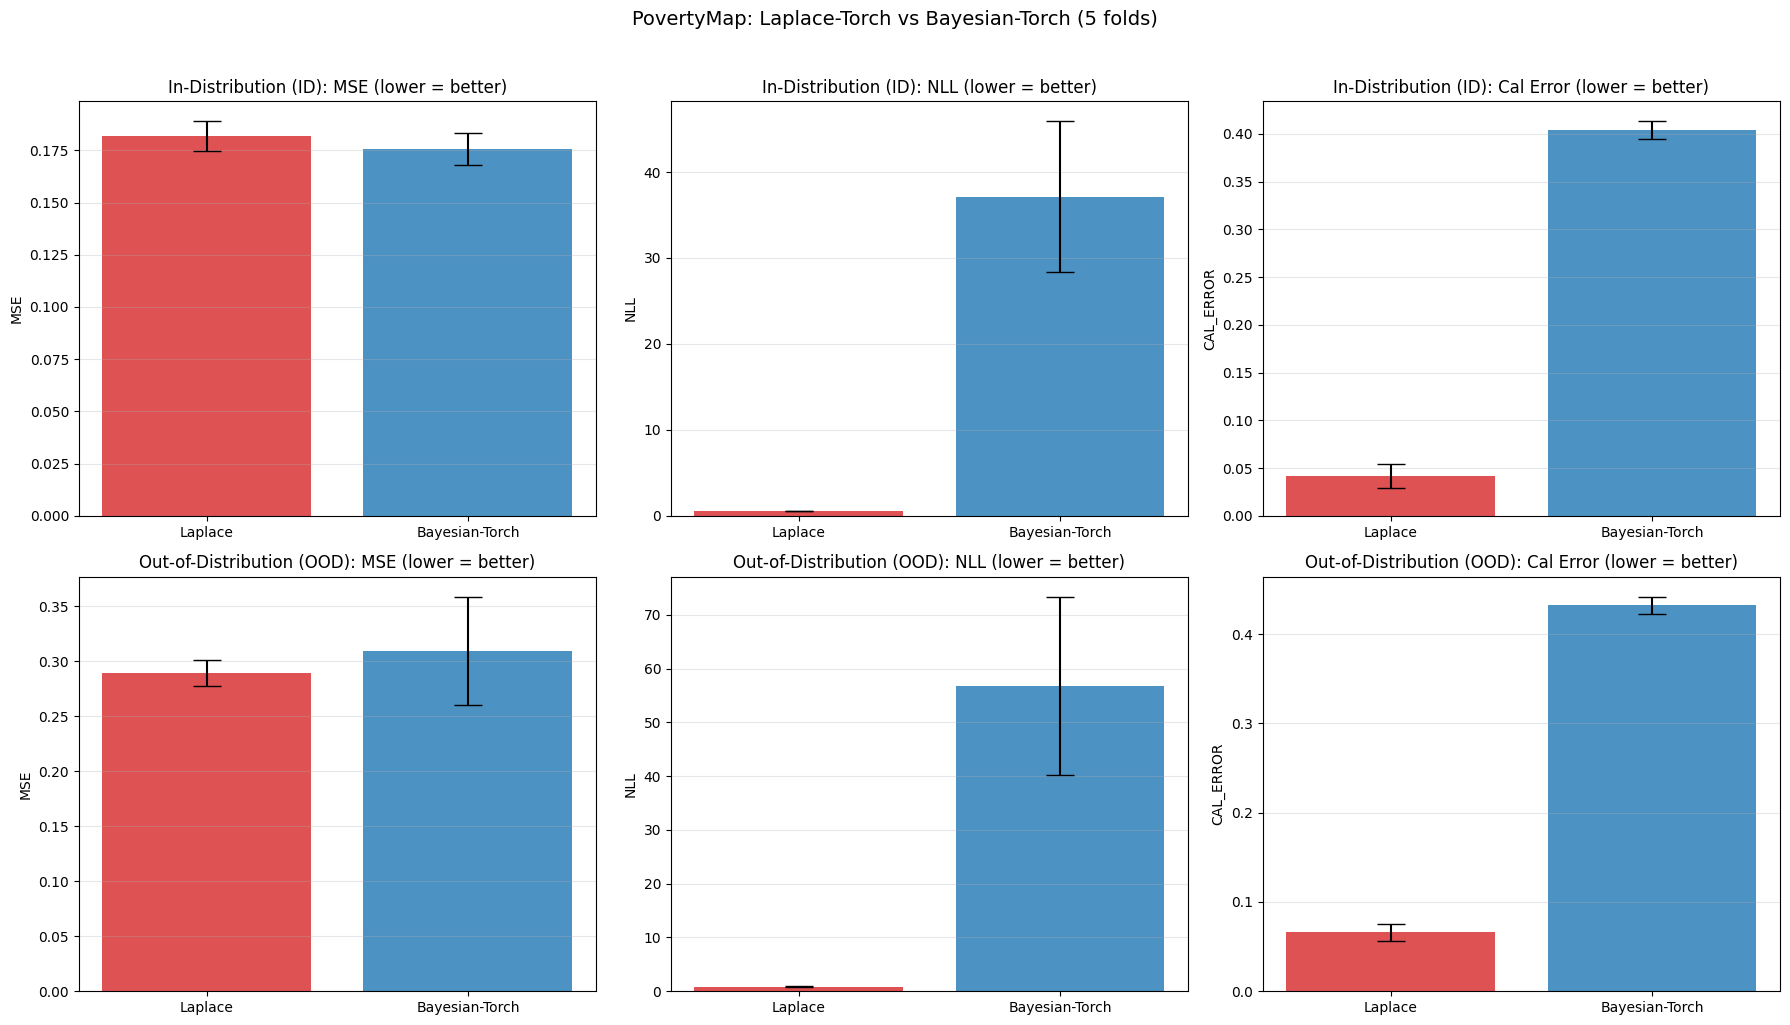

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['mse', 'nll', 'cal_error']
titles = ['MSE (lower = better)', 'NLL (lower = better)', 'Cal Error (lower = better)']
colors = ['#d62728', '#1f77b4']

for row, (split_name, split_label) in enumerate(zip(['id_test', 'test'], ['In-Distribution (ID)', 'Out-of-Distribution (OOD)'])):
    for col, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[row, col]
        la_vals = all_results[split_name]['laplace'][metric]
        bt_vals = all_results[split_name]['bayesian_torch'][metric]
        ax.bar(['Laplace', 'Bayesian-Torch'],
               [np.mean(la_vals), np.mean(bt_vals)],
               yerr=[np.std(la_vals), np.std(bt_vals)],
               capsize=10, color=colors, alpha=0.8)
        ax.set_ylabel(metric.upper())
        ax.set_title(f'{split_label}: {title}')
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('PovertyMap: Laplace-Torch vs Bayesian-Torch (5 folds)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

,mean_epistemic_std,median_epistemic_std,mean_abs_error,corr_epistemic_vs_abs_error,split,method
0,0.045315,0.041303,0.316017,0.065787,ID test,Laplace-Torch
1,0.058910,0.052306,0.307289,0.026730,ID test,Bayesian-Torch
2,0.054254,0.046751,0.413371,0.058238,OOD test,Laplace-Torch
3,0.055306,0.051378,0.413157,0.053497,OOD test,Bayesian-Torch


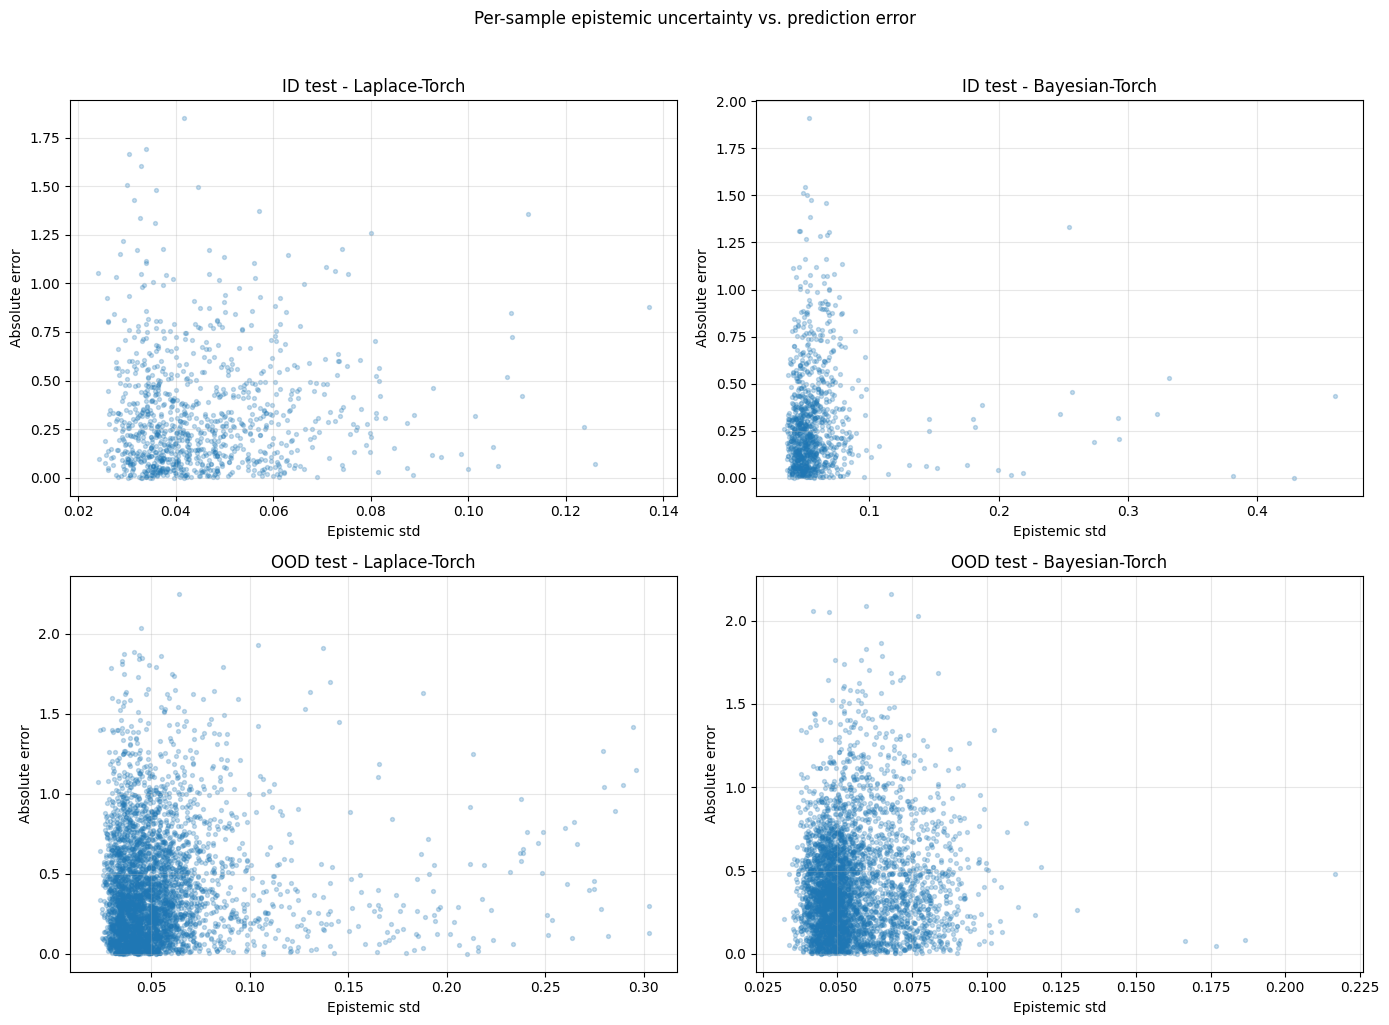

In [ ]:
# Summary/export is handled in the preceding cell.
# This cell is intentionally left as a lightweight placeholder to preserve notebook structure.

## 11. Additional Statistics & Further Analysis
*(This section is intentionally left blank for future inclusion of robust statistical measurements, OOD breakdown analysis, or additional validation plots as requested).*

In [ ]:
print("All tasks complete.")